# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

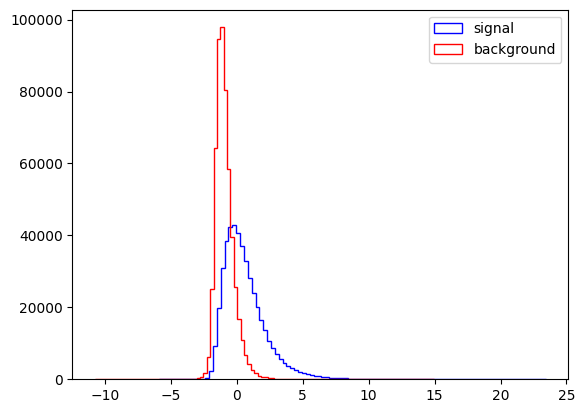

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

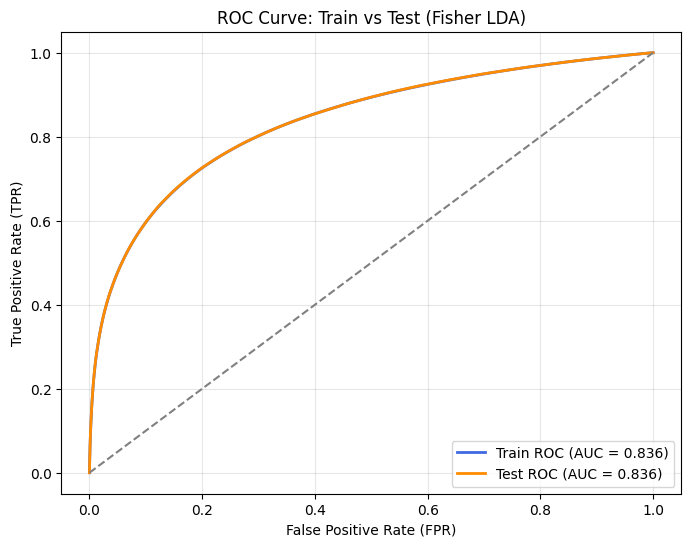

In [7]:
import sklearn.discriminant_analysis as DA
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Initialize and fit Fisher's Linear Discriminant Analysis
Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

# Get decision scores for both sets
Train_scores = Fisher.decision_function(X_Train)
Test_scores = Fisher.decision_function(X_Test)

# Calculate ROC metrics for Training set
fpr_train, tpr_train, _ = roc_curve(y_Train, Train_scores)
auc_train = auc(fpr_train, tpr_train)

# Calculate ROC metrics for Test set
fpr_test, tpr_test, _ = roc_curve(y_Test, Test_scores)
auc_test = auc(fpr_test, tpr_test)

# --- Plotting ---
plt.figure(figsize=(8, 6))

plt.plot(fpr_train, tpr_train, color='royalblue', lw=2, label=f"Train ROC (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f"Test ROC (AUC = {auc_test:.3f})")

# Add a diagonal line representing a random classifier
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: Train vs Test (Fisher LDA)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

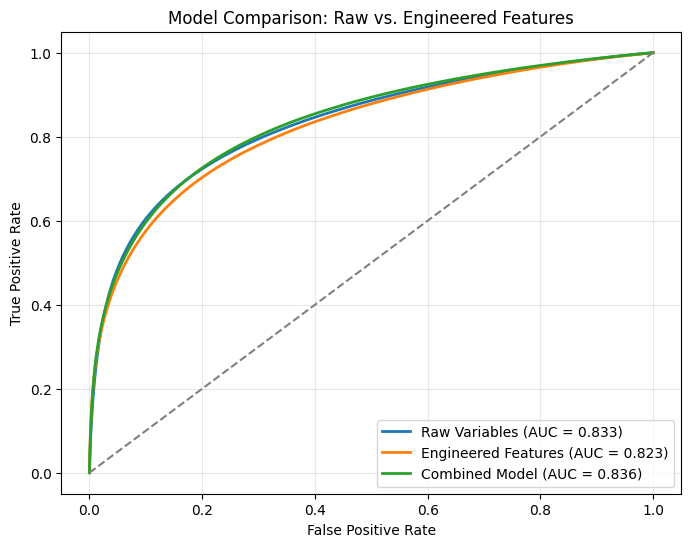

In [8]:
from sklearn.metrics import roc_curve, auc

# --- Feature Selection ---
# Define the raw physical variables
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]

# Identify engineered features (all variables except 'signal' and the raw variables)
# We use set difference to find features present in df columns that aren't in RawNames
VarNames = df.columns.tolist()
FeatureNames = list(set(VarNames) - set(RawNames) - {'signal'})

# --- Model Initialization ---
model_raw = DA.LinearDiscriminantAnalysis()
model_feat = DA.LinearDiscriminantAnalysis()
model_both = DA.LinearDiscriminantAnalysis()

# --- Model Fitting ---
model_raw.fit(df[RawNames], df["signal"])
model_feat.fit(df[FeatureNames], df["signal"])
model_both.fit(df[RawNames + FeatureNames], df["signal"])

# --- Score Generation ---
s_raw = model_raw.decision_function(df[RawNames])
s_feat = model_feat.decision_function(df[FeatureNames])
s_both = model_both.decision_function(df[RawNames + FeatureNames])

# --- ROC and AUC Calculation ---
fpr_r, tpr_r, _ = roc_curve(df["signal"], s_raw)
fpr_f, tpr_f, _ = roc_curve(df["signal"], s_feat)
fpr_b, tpr_b, _ = roc_curve(df["signal"], s_both)

auc_r = auc(fpr_r, tpr_r)
auc_f = auc(fpr_f, tpr_f)
auc_b = auc(fpr_b, tpr_b)

# --- Plotting ---
plt.figure(figsize=(8, 6))

plt.plot(fpr_r, tpr_r, lw=2, label=f"Raw Variables (AUC = {auc_r:.3f})")
plt.plot(fpr_f, tpr_f, lw=2, label=f"Engineered Features (AUC = {auc_f:.3f})")
plt.plot(fpr_b, tpr_b, lw=2, label=f"Combined Model (AUC = {auc_b:.3f})")

# Baseline reference
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison: Raw vs. Engineered Features")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [9]:
# Part a # The three methods that I have chosen are logistic regression, 
# random forrest classifier and decision # trees. I learned from data mining that 
# the random forrest classifier should have a higher accuracy than # the decision 
#tree, although I have never seen it against the logistic regression model.

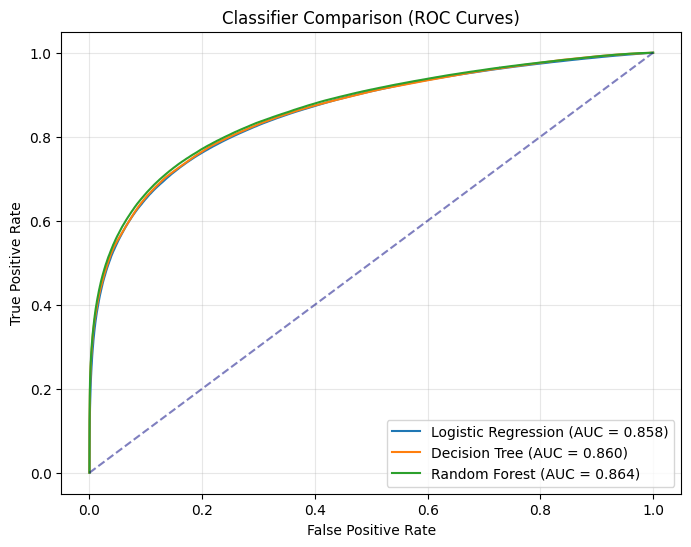

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- 1. Logistic Regression ---
# Good baseline; assumes linear relationships between features and log-odds
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_Train, y_Train)
s_log_test = log_model.predict_proba(X_Test)[:, 1]

# --- 2. Decision Tree ---
# Simple but prone to overfitting; splits data based on feature thresholds
tree_model = DecisionTreeClassifier(max_depth=10)
tree_model.fit(X_Train, y_Train)
s_tree_test = tree_model.predict_proba(X_Test)[:, 1]

# --- 3. Random Forest ---
# An ensemble of trees; usually much more robust and accurate than a single tree
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42 # Added for reproducibility
)
rf_model.fit(X_Train, y_Train)
s_rf_test = rf_model.predict_proba(X_Test)[:, 1]

# --- ROC and AUC Calculations ---
fpr_log, tpr_log, _ = roc_curve(y_Test, s_log_test)
fpr_tree, tpr_tree, _ = roc_curve(y_Test, s_tree_test)
fpr_rf, tpr_rf, _ = roc_curve(y_Test, s_rf_test)

auc_log = auc(fpr_log, tpr_log)
auc_tree = auc(fpr_tree, tpr_tree)
auc_rf = auc(fpr_rf, tpr_rf)

# --- Visualization ---
plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# Chance line (Random Guessing)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison (ROC Curves)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

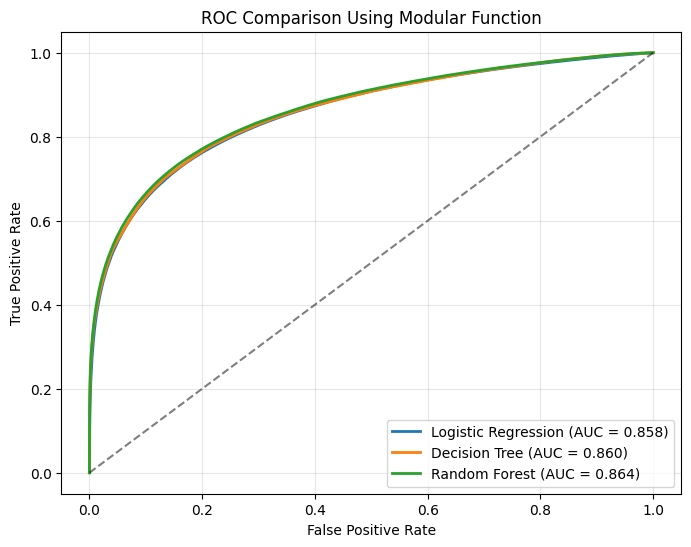

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def run_model(model, X_train, y_train, X_test, y_test, name="model"):
    """
    Fits the provided model, calculates ROC metrics, and adds the 
    curve to the current active matplotlib plot.
    """
    # Fit the model
    model.fit(X_train, y_train)

    # Get probability scores for the positive class (column 1)
    scores = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve and Area Under the Curve (AUC)
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    # Add curve to the existing plot
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:0.3f})")

    return roc_auc

# --- Execution ---

# Create a single figure for comparison
plt.figure(figsize=(8, 6))

# Define the models
log_model = LogisticRegression(max_iter=1000)
tree_model = DecisionTreeClassifier(max_depth=10)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)

# Run each model using the function
auc_log = run_model(log_model, X_Train, y_Train, X_Test, y_Test, "Logistic Regression")
auc_tree = run_model(tree_model, X_Train, y_Train, X_Test, y_Test, "Decision Tree")
auc_rf = run_model(rf_model, X_Train, y_Train, X_Test, y_Test, "Random Forest")

# Add the diagonal 50/50 baseline
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

# Formatting the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison Using Modular Function")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mn/mng3vpnn66d9h65m1_86tdfr0000gn/T/ipykernel_22419/3987744819.py:46: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Significance ($S / \sqrt{S+B}$)")


Optimal Threshold: 0.374
Maximum Significance (σ): 520.135


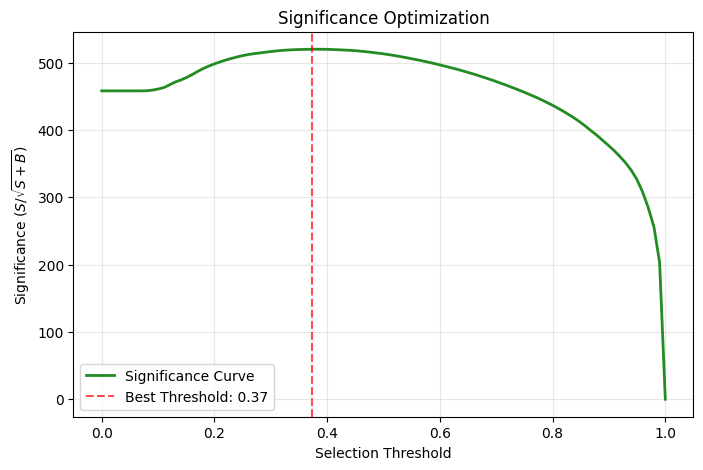

In [12]:
# 1. Extract scores from the best model (using Random Forest as an example)
# Make sure rf_model has already been fitted in your previous cell!
scores = rf_model.predict_proba(X_Test)[:, 1]

# 2. Setup threshold range and storage
thresholds = np.linspace(0, 1, 100)
significance = []

# 3. Calculate significance for each threshold
for t in thresholds:
    # Apply the cut: events with scores > t are classified as Signal (1)
    preds = scores > t
    
    # Count Signal (N_S) and Background (N_B) passing the cut
    N_S = np.sum((preds == 1) & (y_Test == 1))
    N_B = np.sum((preds == 1) & (y_Test == 0))
    
    # Calculate Statistical Significance: S / sqrt(S + B)
    if (N_S + N_B) > 0:
        sigma = N_S / np.sqrt(N_S + N_B)
    else:
        sigma = 0
        
    significance.append(sigma)

# 4. Identify the optimal point
best_idx = np.argmax(significance)
best_threshold = thresholds[best_idx]
best_sigma = significance[best_idx]

print(f"Optimal Threshold: {best_threshold:.3f}")
print(f"Maximum Significance (σ): {best_sigma:.3f}")

# 5. Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(thresholds, significance, color='forestgreen', lw=2, label="Significance Curve")

# Highlight the best threshold
plt.axvline(best_threshold, color='red', linestyle='--', alpha=0.7, 
            label=f"Best Threshold: {best_threshold:.2f}")

plt.xlabel("Selection Threshold")
plt.ylabel("Significance ($S / \sqrt{S+B}$)")
plt.title("Significance Optimization")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

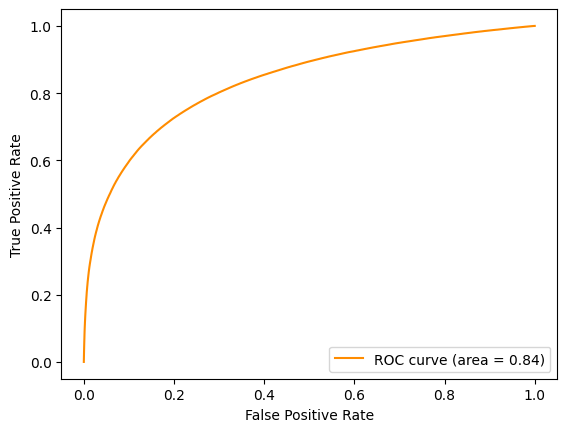

In [13]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [14]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_score, recall_score,
    f1_score, accuracy_score,
    confusion_matrix
)

# --- Manual Calculation for Random Forest ---

# Use the scores and threshold derived from previous steps
scores_rf = rf_model.predict_proba(X_Test)[:, 1]
y_pred_rf = (scores_rf > best_threshold).astype(int)

# Calculate standard metrics
roc_auc = auc(*roc_curve(y_Test, scores_rf)[:2])
precision = precision_score(y_Test, y_pred_rf)
recall = recall_score(y_Test, y_pred_rf)
f1 = f1_score(y_Test, y_pred_rf)
accuracy = accuracy_score(y_Test, y_pred_rf)

# Calculate FPR from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_Test, y_pred_rf).ravel()
FPR = fp / (fp + tn)

print("--- Model Performance (Random Forest) ---")
print(f"AUC:              {roc_auc:.3f}")
print(f"Accuracy:         {accuracy:.3f}")
print(f"Precision:        {precision:.3f}")
print(f"Recall (TPR):     {recall:.3f}")
print(f"F1 Score:         {f1:.3f}")
print(f"FPR:              {FPR:.3f}")
print(f"Max Significance: {best_sigma:.3f}\n")


# --- Part B: Unified Evaluation Function ---

def evaluate_model(model, X_train, y_train, X_test, y_test, threshold):
    """
    Fits a model and returns a list of key performance metrics 
    based on a specific decision threshold.
    """
    # Fit and Predict
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_test)[:, 1]
    y_pred = (scores > threshold).astype(int)

    # Metrics
    fpr_list, tpr_list, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr_list, tpr_list)
    
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Confusion Matrix derived metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr_val = fp / (fp + tn)

    return {
        "AUC": roc_auc, 
        "Accuracy": acc, 
        "Precision": prec, 
        "Recall": rec, 
        "F1": f1, 
        "FPR": fpr_val
    }


--- Model Performance (Random Forest) ---
AUC:              0.864
Accuracy:         0.781
Precision:        0.747
Recall (TPR):     0.790
F1 Score:         0.768
FPR:              0.226
Max Significance: 520.135

